# Task 2 - Exploratory Data Analysis (EDA)
## Airbnb Listings Dataset

### Objective: The objective of this analysis is to explore the Airbnb Listings dataset using Python, Pandas, Matplotlib, and Seaborn. 
The analysis focuses on understanding the data, identifying patterns and relationships, detecting potential outliers, and generating meaningful insights through visualizations.

### Dataset Overview : The dataset contains Airbnb listings from New York City. It includes information about listing prices, room types, property types, neighbourhoods, accommodation capacity, reviews, availability, and other listing characteristics.
The dataset contains **30,234 listings and 90 columns**.

In [1]:
import pandas as pd
df = pd.read_csv("listings.csv.gz")

In [2]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260810212434,2026-08-11,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.78,4.78,NaN,NaN,3,0,3,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260810212434,2026-08-11,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.70,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260810212434,2026-08-11,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming month-to-month home away from ho...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04
3,146726,https://www.airbnb.com/rooms/146726,20260810212434,2026-08-11,city scrape,Cozy authentic residence near Central Park,We are back - renovated and better! <br />Only...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,709334,...,4.94,4.56,4.72,NaN,NaN,1,1,0,0,0.10
4,148201,https://www.airbnb.com/rooms/148201,20260810212434,2026-08-11,previous scrape,NYC - Sunny Greenwich Village 1br,Due to the current NYC Airbnb laws - specifica...,NaN,https://a0.muscache.com/pictures/937604/f87860...,715807,...,4.88,4.88,4.81,NaN,NaN,1,1,0,0,0.10


In [3]:
df.shape

(30234, 90)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30234 entries, 0 to 30233
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30234 non-null  int64  
 1   listing_url                                   30234 non-null  object 
 2   scrape_id                                     30234 non-null  int64  
 3   last_scraped                                  30234 non-null  object 
 4   source                                        30234 non-null  object 
 5   name                                          30233 non-null  object 
 6   description                                   28995 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   30234 non-null  object 
 9   host_id                                       30234 non-null 

In [5]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

host_acceptance_rate           30234
host_response_rate             30234
neighborhood_overview          30234
instant_bookable               30234
neighbourhood                  30234
host_since                     30234
calendar_updated               30234
host_verifications             30234
host_total_listings_count      30234
host_neighbourhood             30234
host_thumbnail_url             30234
host_response_time             30234
license                        25015
host_about                     12488
bedrooms                       12464
bathrooms                      10373
price_quote_price_per_night     9913
price_quote_total_price         9913
price                           9903
estimated_revenue_l365d         9903
beds                            9775
review_scores_location          8318
review_scores_value             8318
review_scores_checkin           8317
review_scores_accuracy          8315
review_scores_communication     8312
review_scores_rating            8309
l

In [6]:
df.duplicated().sum()

0

### Data Quality Observations

- The dataset contains missing values across several columns. Some columns are completely empty, while others have partial missing values.
- The `price` column has 9,903 missing values, so price-based analysis should use only listings with recorded prices.
- No completely duplicated rows were found in the dataset.

In [7]:
df['room_type'].value_counts()

room_type
Entire home/apt    16693
Private room       12867
Hotel room           486
Shared room          188
Name: count, dtype: int64

In [8]:
df['property_type'].value_counts()

property_type
Entire rental unit             13045
Private room in rental unit     6635
Private room in home            2501
Room in hotel                   2009
Entire home                     1204
                               ...  
Private room in ranch              1
Shared room in guesthouse          1
Private room in tent               1
Private room in dorm               1
Room in rental unit                1
Name: count, Length: 68, dtype: int64

In [9]:
df['property_type'].value_counts().head(10)

property_type
Entire rental unit             13045
Private room in rental unit     6635
Private room in home            2501
Room in hotel                   2009
Entire home                     1204
Private room in townhouse       1030
Entire condo                     945
Entire townhouse                 416
Private room in condo            378
Entire loft                      377
Name: count, dtype: int64

### Categorical Data Observations

- `Entire home/apt` is the most common room type with 16,693 listings, followed by `Private room` with 12,867 listings.
- The dataset contains 68 different property types, with `Entire rental unit` being the most common property type.

### Descriptive Statistics

Descriptive statistics are used to summarize the main characteristics of numerical variables in the dataset. Measures such as mean, median, minimum, maximum, and quartiles help us understand the distribution and identify unusual values.

In [10]:
df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.023400e+04,3.023400e+04,0.0,3.023400e+04,2.967100e+04,0.0,29671.000000,29671.000000,29671.000000,29671.000000,...,21917.000000,21922.000000,21916.000000,21916.000000,0.0,30234.000000,30234.000000,30234.000000,30234.000000,21925.000000
mean,6.363009e+17,2.026081e+13,NaN,1.004816e+16,1.471941e+18,NaN,8.421725,5.286509,6.798760,5.393650,...,4.833656,4.815979,4.743830,4.627536,NaN,52.350466,43.137263,8.199047,0.060131,0.918840
std,6.273967e+17,2.878954e+00,NaN,1.305816e+17,3.405743e+16,NaN,4.008837,3.461519,3.930537,3.403809,...,0.388946,0.431942,0.395915,0.505979,NaN,162.804024,161.169842,33.665336,0.731392,2.336176
min,2.539000e+03,2.026081e+13,NaN,1.678000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.057865e+07,2.026081e+13,NaN,2.085777e+07,1.462881e+18,NaN,5.000000,2.000000,3.000000,2.000000,...,4.820000,4.810000,4.670000,4.520000,NaN,1.000000,0.000000,0.000000,0.000000,0.090000
50%,6.776256e+17,2.026081e+13,NaN,1.074344e+08,1.465525e+18,NaN,9.000000,5.000000,7.000000,6.000000,...,4.950000,4.960000,4.850000,4.750000,NaN,2.000000,1.000000,0.000000,0.000000,0.270000
75%,1.174801e+18,2.026081e+13,NaN,4.021871e+08,1.469613e+18,NaN,11.000000,8.000000,10.000000,8.000000,...,5.000000,5.000000,5.000000,4.920000,NaN,12.000000,3.000000,2.000000,0.000000,0.990000
max,1.748741e+18,2.026081e+13,NaN,1.748739e+18,1.748741e+18,NaN,18.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,908.000000,908.000000,231.000000,16.000000,115.860000


In [11]:
numeric_cols = ['accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'review_scores_rating',
 'availability_365',
 'estimated_revenue_l365d']
df[numeric_cols].describe()

,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,reviews_per_month,review_scores_rating,availability_365,estimated_revenue_l365d
count,30234.000000,19861.000000,17770.000000,20459.000000,30228.000000,30234.000000,21925.000000,21925.000000,30234.000000,20331.000000
mean,2.851227,1.210110,1.614069,1.717777,26.748478,32.881094,0.918840,4.729816,190.031818,17344.265309
std,1.942334,0.542165,0.930329,1.249195,28.302046,81.197439,2.336176,0.456788,142.023920,36016.711740
min,1.000000,0.500000,0.000000,1.000000,1.000000,0.000000,0.010000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,30.000000,0.000000,0.090000,4.670000,17.000000,0.000000
50%,2.000000,1.000000,1.000000,1.000000,30.000000,4.000000,0.270000,4.860000,222.000000,0.000000
75%,4.000000,1.000000,2.000000,2.000000,30.000000,29.000000,0.990000,5.000000,332.000000,21008.500000
max,16.000000,15.500000,19.000000,42.000000,1124.000000,4735.000000,115.860000,5.000000,365.000000,882471.000000


In [12]:
df['price'].head(10)

0    $105.01
1    $118.50
2     $84.48
3    $195.47
4        NaN
5    $140.82
6    $536.75
7        NaN
8    $212.00
9    $360.07
Name: price, dtype: object

In [13]:
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price'].dtype

dtype('float64')

### Data Cleaning – Price Column

The `price` column was initially stored as text with a dollar sign. To perform numerical analysis, the dollar sign was removed and the values were converted into a numeric format. Invalid or missing values were converted to NaN.

In [14]:
df['price'].describe()

count    19825.000000
mean       216.916950
std        166.557363
min          4.580000
25%         99.070000
50%        171.190000
75%        276.000000
max        999.870000
Name: price, dtype: float64

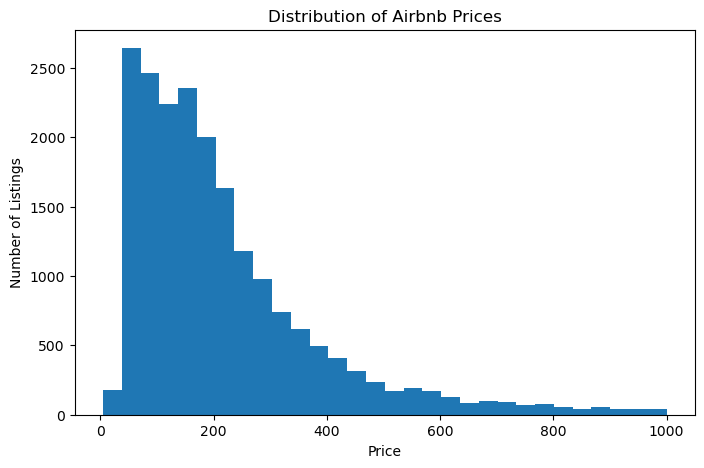

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['price'].dropna(), bins=30)
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Number of Listings')
plt.show()

### Visualization 1: Distribution of Airbnb Prices

**Question:** What does the distribution of Airbnb prices look like?

A histogram is used to understand how Airbnb prices are distributed across the listings.

**Observation:** Airbnb prices are right-skewed. Most listings are concentrated at relatively lower prices, while fewer listings have higher prices, creating a long right tail.

In [16]:
room_price = df.groupby('room_type')['price'].mean()

In [17]:
room_price

room_type
Entire home/apt    258.716563
Hotel room         422.413864
Private room       158.882606
Shared room        147.725430
Name: price, dtype: float64

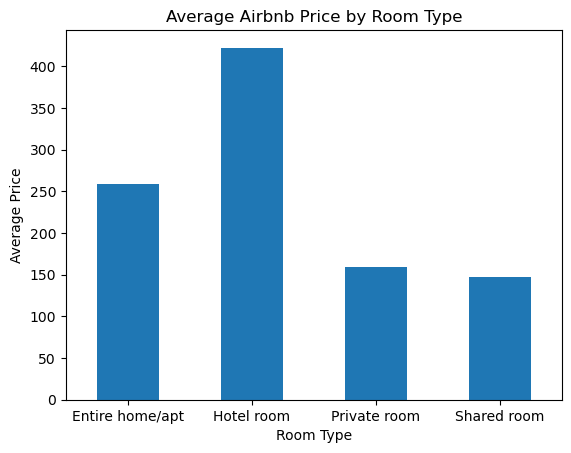

In [18]:
room_price.plot(kind='bar')

plt.title('Average Airbnb Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show()

### Visualization 2: Average Airbnb Price by Room Type

**Question:** Does the average Airbnb price differ by room type?

A bar chart is used to compare the average price across different room types.

**Observation:** Average Airbnb prices vary by room type. Hotel rooms have the highest average price at approximately $422, while shared rooms have the lowest average price at approximately $148.

In [19]:
neighbourhood_price = df.groupby('neighbourhood_cleansed')['price'].mean()

In [20]:
neighbourhood_price.sort_values(ascending=False).head(10)

neighbourhood_cleansed
Civic Center          487.595000
NoHo                  413.660000
Hollis Hills          411.315000
SoHo                  410.738759
Tribeca               406.333784
Financial District    378.005653
Greenwich Village     377.916437
Midtown               355.598001
Cobble Hill           347.630500
Theater District      335.154735
Name: price, dtype: float64

In [21]:
neighbourhood_count = df.groupby('neighbourhood_cleansed')['price'].count()

In [22]:
neighbourhood_count.sort_values(ascending=False).head(10)

neighbourhood_cleansed
Bedford-Stuyvesant    1379
Midtown               1356
Hell's Kitchen         995
Harlem                 948
Upper East Side        824
Upper West Side        725
Williamsburg           705
Crown Heights          592
Bushwick               572
Chelsea                435
Name: price, dtype: int64

In [23]:
neighbourhood_summary = pd.DataFrame({
    'Average Price': neighbourhood_price,
    'Listing Count': neighbourhood_count
})

In [24]:
neighbourhood_summary.sort_values('Average Price', ascending=False).head(10)

,Average Price,Listing Count
neighbourhood_cleansed,,
Civic Center,487.595000,2
NoHo,413.660000,11
Hollis Hills,411.315000,2
SoHo,410.738759,145
Tribeca,406.333784,74
Financial District,378.005653,329
Greenwich Village,377.916437,87
Midtown,355.598001,1356
Cobble Hill,347.630500,20


In [25]:
neighbourhood_count = df.groupby('neighbourhood_cleansed')['price'].count()
neighbourhood_summary = pd.DataFrame({
    'Average Price': neighbourhood_price,
    'Listing Count': neighbourhood_count
})
neighbourhood_summary.sort_values('Average Price', ascending=False).head(10)

,Average Price,Listing Count
neighbourhood_cleansed,,
Civic Center,487.595000,2
NoHo,413.660000,11
Hollis Hills,411.315000,2
SoHo,410.738759,145
Tribeca,406.333784,74
Financial District,378.005653,329
Greenwich Village,377.916437,87
Midtown,355.598001,1356
Cobble Hill,347.630500,20


In [26]:
reliable_neighbourhoods = neighbourhood_summary[
    neighbourhood_summary['Listing Count'] >= 100]
top_neighbourhoods = reliable_neighbourhoods.sort_values('Average Price',ascending=False).head(10)

In [27]:
top_neighbourhoods

,Average Price,Listing Count
neighbourhood_cleansed,,
SoHo,410.738759,145
Financial District,378.005653,329
Midtown,355.598001,1356
Theater District,335.154735,283
West Village,326.613272,162
Murray Hill,316.012716,335
Lower East Side,299.673870,323
Greenpoint,296.464793,242
Chelsea,271.750391,435


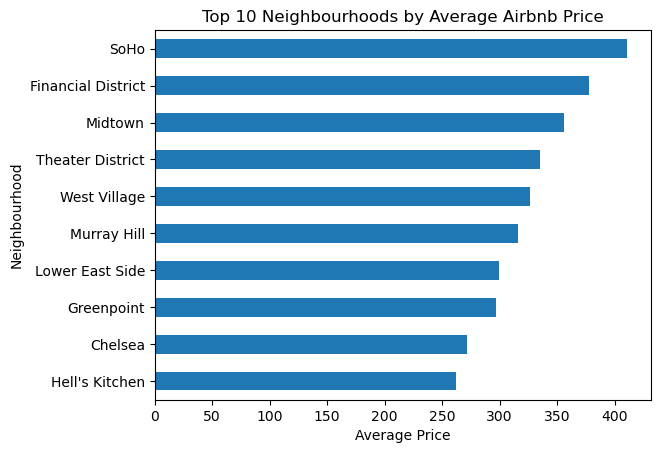

In [28]:
top_neighbourhoods['Average Price'].sort_values().plot(kind='barh')

plt.title('Top 10 Neighbourhoods by Average Airbnb Price')
plt.xlabel('Average Price')
plt.ylabel('Neighbourhood')
plt.show()

### Visualization 3: Average Airbnb Price by Neighbourhood

**Question:** Which neighbourhoods have the highest average Airbnb prices?

The analysis uses neighbourhoods with at least 100 listings having recorded prices to reduce the influence of very small sample sizes.

**Observation:** Among neighbourhoods with at least 100 listings with recorded prices, SoHo has the highest average Airbnb price at approximately $410.74, followed by Financial District at approximately $378.01.

In [29]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 99.07
Q3: 276.0
IQR: 176.93


In [30]:
upper_limit = Q3 + 1.5 * IQR

print("Upper outlier limit:", upper_limit)

Upper outlier limit: 541.395


In [31]:
outliers = df[df['price'] > upper_limit]

len(outliers)

1151

In [32]:
outlier_percentage = (len(outliers) / df['price'].notna().sum()) * 100

print("Potential price outliers:", len(outliers))
print("Percentage of priced listings:", round(outlier_percentage, 2), "%")

Potential price outliers: 1151
Percentage of priced listings: 5.81 %


Observation: The IQR method identifies 1,151 potential high-price outliers, representing 5.81% of listings with recorded prices. 
These listings should be investigated individually because a statistical outlier is not necessarily a data-entry error.

In [33]:
df[['accommodates', 'price']].corr()

,accommodates,price
accommodates,1.000000,0.469014
price,0.469014,1.000000


plt.figure(figsize=(8, 5))

plt.scatter(df['accommodates'], df['price'], alpha=0.3)

plt.title('Relationship Between Accommodation Capacity and Price')
plt.xlabel('Number of Guests Accommodated')
plt.ylabel('Price')
plt.show()

Observation: The scatter plot shows a moderate positive relationship between accommodation capacity and price. 
Listings that accommodate more guests generally tend to have higher prices, although there is substantial variation at each capacity level.

In [34]:
corr_cols = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'availability_365',
    'price',
    'estimated_revenue_l365d'
]
correlation_matrix = df[corr_cols].corr()
correlation_matrix

,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,reviews_per_month,review_scores_rating,availability_365,price,estimated_revenue_l365d
accommodates,1.000000,0.438806,0.649982,0.755112,-0.036970,-0.008378,0.023499,-0.011392,0.097182,0.469014,0.206982
bathrooms,0.438806,1.000000,0.617020,0.482750,0.009255,-0.061826,-0.031312,-0.000808,0.058687,0.258986,0.116720
bedrooms,0.649982,0.617020,1.000000,0.732269,0.007885,-0.020943,-0.000463,0.018051,0.087130,0.261334,0.182974
beds,0.755112,0.482750,0.732269,1.000000,-0.088885,0.021032,0.024124,0.011555,0.045080,0.385169,0.234773
minimum_nights,-0.036970,0.009255,0.007885,-0.088885,1.000000,-0.130887,-0.199258,0.007947,-0.005304,-0.282489,-0.354300
number_of_reviews,-0.008378,-0.061826,-0.020943,0.021032,-0.130887,1.000000,0.627605,0.053121,0.022506,-0.006668,0.268973
reviews_per_month,0.023499,-0.031312,-0.000463,0.024124,-0.199258,0.627605,1.000000,0.020676,0.108880,0.098046,0.292409
review_scores_rating,-0.011392,-0.000808,0.018051,0.011555,0.007947,0.053121,0.020676,1.000000,-0.076727,0.054219,0.089348
availability_365,0.097182,0.058687,0.087130,0.045080,-0.005304,0.022506,0.108880,-0.076727,1.000000,0.028460,-0.100424
price,0.469014,0.258986,0.261334,0.385169,-0.282489,-0.006668,0.098046,0.054219,0.028460,1.000000,0.389847


In [35]:
import seaborn as sns

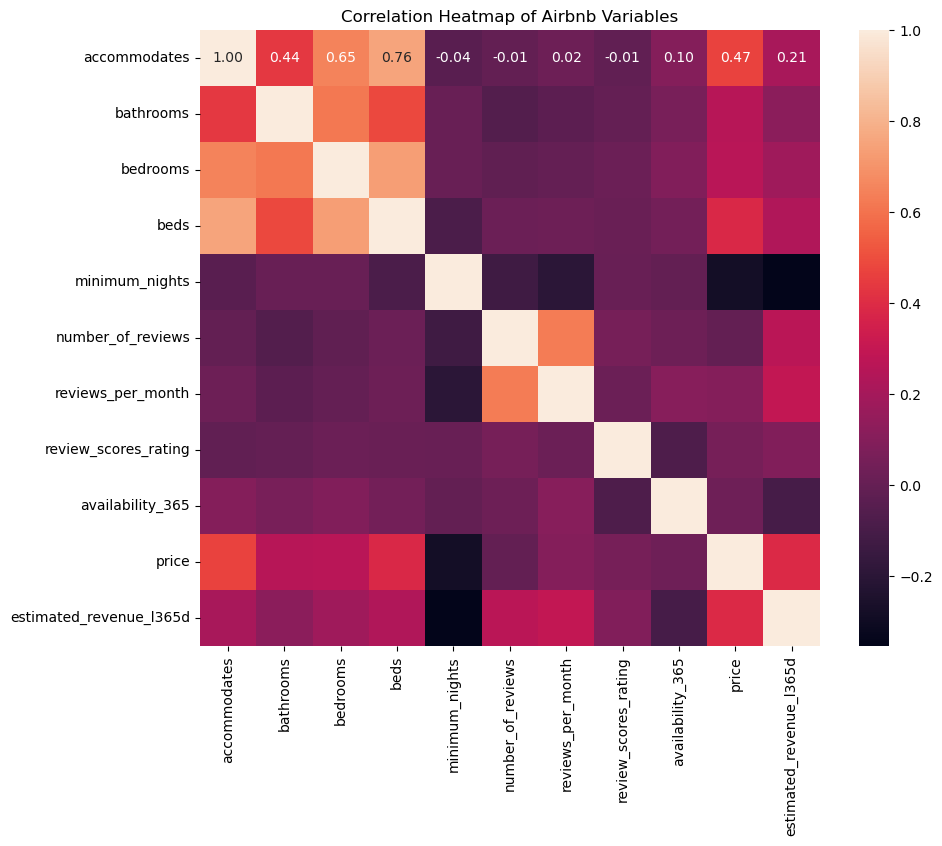

In [36]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap of Airbnb Variables')
plt.show()

### Visualization 5: Accommodation Capacity vs Price

**Question:** Do listings that accommodate more guests tend to have higher prices?

A scatter plot is used to examine the relationship between accommodation capacity and price.

Observation: The correlation heatmap shows strong positive relationships among property-
capacity variables. accommodates is strongly correlated with beds (0.76) and moderately correlated with bedrooms (0.65). 
accommodates also has a moderate positive correlation with price (0.47). These relationships suggest that larger properties generally tend to have higher prices.

In [37]:
room_price

room_type
Entire home/apt    258.716563
Hotel room         422.413864
Private room       158.882606
Shared room        147.725430
Name: price, dtype: float64

In [38]:
df['last_review'].head()

0    2026-05-28
1    2026-06-30
2    2025-10-07
3    2018-01-05
4    2013-05-31
Name: last_review, dtype: object

In [39]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

In [40]:
df['last_review'].dtype

dtype('<M8[ns]')

In [41]:
df['review_year'] = df['last_review'].dt.year
df[['last_review', 'review_year']].head()

,last_review,review_year
0,2026-05-28,2026.0
1,2026-06-30,2026.0
2,2025-10-07,2025.0
3,2018-01-05,2018.0
4,2013-05-31,2013.0


In [42]:
review_year_counts = df['review_year'].value_counts().sort_index()
review_year_counts

review_year
2011.0       2
2012.0       8
2013.0      20
2014.0      57
2015.0     409
2016.0     629
2017.0     471
2018.0     548
2019.0     864
2020.0     807
2021.0     513
2022.0     965
2023.0    3110
2024.0    1541
2025.0    2992
2026.0    8989
Name: count, dtype: int64

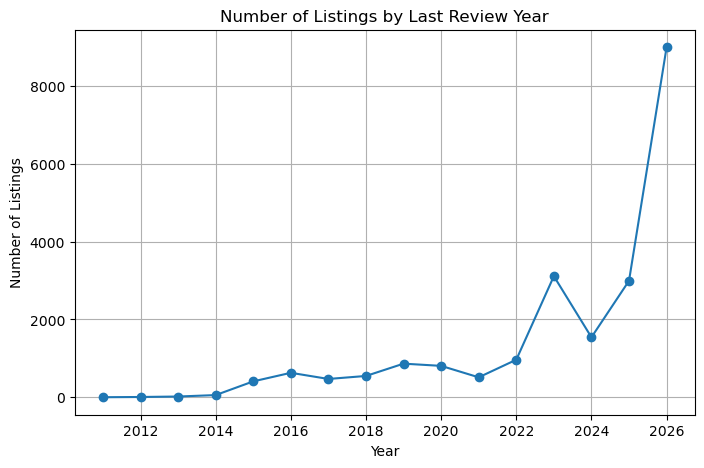

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(review_year_counts.index, review_year_counts.values, marker='o')

plt.title('Number of Listings by Last Review Year')
plt.xlabel('Year')
plt.ylabel('Number of Listings')
plt.grid(True)

plt.show()

### Visualization 6: Listings by Last Review Year

**Question:** How does the number of listings with a recorded last review vary over the years?

A line chart is used because the year is a time-based variable and a line chart makes changes and fluctuations over time easier to identify.

Observation: The number of listings with a recorded last review shows an overall increasing trend over the years, with a noticeable rise after 2022. 
The highest number of listings is observed in 2026, with 8,989 listings, while 2023 and 2025 also show relatively high values. 
The fluctuations indicate that review activity has varied across years.

## Top 3 Key Insights

1. **Airbnb prices are right-skewed:** Most listings are concentrated at lower-to-moderate prices, while a smaller number of listings have substantially higher prices.

2. **Room type influences average price:** Hotel rooms have the highest average price, whilze shared rooms have the lowest average price in this dataset.

3. **Larger listings tend to have higher prices:** Accommodation capacity has a moderate positive correlation with price (0.47), indicating that listings accommodating more guests generally tend to be more expensive.

## Interview Questions

### 1. How would you distinguish a genuine outlier from a data-entry error?

I would first identify outliers using statistical methods such as the IQR method or Z-score. I would then investigate the unusual records using domain knowledge and related variables. If the value is unusual but logically possible, it may be a genuine outlier. If it is impossible, inconsistent, or caused by incorrect data entry, it may be a data-quality error. Therefore, an outlier should not automatically be removed.

### 2. What is the difference between correlation and causation, and why does it matter in EDA?

Correlation indicates that two variables are related, whereas causation means that a change in one variable directly causes a change in another. Correlation alone does not prove cause and effect. For example, accommodation capacity and Airbnb price have a moderate positive correlation of 0.47, but this does not prove that increasing accommodation capacity directly causes the price to increase.

### 3. Which chart would you use to show a trend over 12 months and why?

I would use a line chart because the data is time-based. Connecting the observations in chronological order makes it easy to identify increases, decreases, fluctuations, and overall trends.